### 1. Collect the evidence

The number of M&Ms could be miscounted. This can be checked by making sure that the sum of the numbers of each M&M colors is equivalent to the number of M&Ms in the bag. 

### 2. Decide what "random" means  
##### Describe two possible meanings od "random"
1. Larger bags appear more consistent than smaller bags  
2. Every color is equally likely
##### One meaning for investigation -> A question
- Every color is equally likely -> Is every color equally likely to appear in a bag of M&M's? 
##### Prediction: 
- I predict that across many bags of M&M's, the colors appear (on average) the same number of times in each bag because they are equally as likely to appear. 

### 3. Plan before you code:  
INPUT: M&M color counts collected by the class
1. Load the dataset and check  
- 1.1 number of bags
- 1.2 available columns
- 1.3 column types
- 1.4 missing values
- 1.5 any impossible counts. 
2. Fix missing values and impossible counts
- 2.1 convert to NanN
- 2.2 Document changes
3. Find the total count of each data entry
4. Find aggregate values for total count.
5. Convert color counts into proportions.
6. Compare individual bags with the complete class dataset.
7. Define how a bag will be judged typical or unusual.
8. Create a visualization of the most important result.
9. Create an extention to prove/disprove randomness. 
10. Use the evidence to answer the research question.  
  
OUTPUT: Tables, a visualization, and a defensible conclusion.


### 4. pandas DataFrame

In [ ]:
# importing packages for assignment 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: reading in the csv table

df = pd.read_csv("MMs_.csv")

# giving a bag id to each bag for later steps
df["bag_id"] = ["Bag_" + str(i+1).zfill(2) for i in range(len(df))]

df.head()

,Fav,Random,Blues,Reds,Greens,Yellows,Oranges,Browns,bag_id
0,Blue,Yes,6,2,1,2,2.0,3,Bag_01
1,Green,Yes,4,2,4,1,4.0,0,Bag_02
2,Blue,No,3,3,2,2,2.0,4,Bag_03
3,Blue,Yes,6,1,2,4,0.0,3,Bag_04
4,Red,Maybe,4,1,3,5,1.0,1,Bag_05


In [ ]:
# Step 1.1 - 1.5

print(f"Number of bags: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print(f"Number of colors: {df.shape[1]-2}") # the "-2" comes from remiving the string columns
print(df.info())
print(df.describe())
print(df.isna().sum())

Number of bags: 29
Number of columns: 9
Number of colors: 7
<class 'pandas.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Fav      29 non-null     str    
 1   Random   29 non-null     str    
 2   Blues    29 non-null     int64  
 3   Reds     29 non-null     int64  
 4   Greens   29 non-null     int64  
 5   Yellows  29 non-null     int64  
 6   Oranges  29 non-null     float64
 7   Browns   29 non-null     int64  
 8   bag_id   29 non-null     str    
dtypes: float64(1), int64(5), str(3)
memory usage: 2.6 KB
None
           Blues       Reds     Greens    Yellows    Oranges     Browns
count  29.000000  29.000000  29.000000  29.000000  29.000000  29.000000
mean    4.241379   2.413793   2.517241   2.931034   2.327586   1.448276
std     2.811395   1.268217   1.454566   1.730628   1.804141   1.212618
min     1.000000   0.000000   1.000000   0.000000   0.000000   0.000000
25%     

In [ ]:
# Step 2: 

# Make oranges row int64 as well
df["Oranges"] = df["Oranges"].astype("int64")
# row 15 is dropped because it has an impossible number of orannge candies
# row 18 is dropped because it is likely an entry error, it has too many m&m's
df = df.drop(index=[15, 18])
df = df.reset_index(drop=True)

# check changes were made
print(df.info())


<class 'pandas.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   Fav      27 non-null     str  
 1   Random   27 non-null     str  
 2   Blues    27 non-null     int64
 3   Reds     27 non-null     int64
 4   Greens   27 non-null     int64
 5   Yellows  27 non-null     int64
 6   Oranges  27 non-null     int64
 7   Browns   27 non-null     int64
 8   bag_id   27 non-null     str  
dtypes: int64(6), str(3)
memory usage: 2.4 KB
None


In [ ]:
# Step 3

color_cols = ["Blues", "Reds", "Greens", "Yellows", "Oranges", "Browns"]
df["total"] = df[color_cols].sum(axis=1)

### 5. Reconnect with NumPy
Explain one similarity between a Series and an array:
- Both store sequences of values and allow aggregate and mathematical operations.

Explain one useful feature pandas adds: 
- Rather than having numeric indices, series allow for key-values pairing for indices. 

Explain why standard deviations may differ unless the same degrees-of-freedom convention is used: 
- By default, pandas uses the df of (n-1), which is commonly used in stats. Numpy, on the other hand, divides by (n-0), or just n. Therefore, to use standard deviation in pandas the sam way as you would numpy, you must set the ddof = 0. 

In [ ]:
totals_series = df["total"]
totals_array = totals_series.to_numpy()

# Step 4: array

print("Aggregates of total count of M&Ms (Array)")
print("Mean: ", np.mean(totals_array))
print("Median: ",np.median(totals_array))
print("Min: ",np.min(totals_array))
print("Max: ",np.max(totals_array))
print("Standard deviation: ",np.std(totals_array), "\n")

# Step 4: series

print("Aggregates of total count of M&Ms (Series)")
print("Mean: ", totals_series.mean())
print("Median: ",totals_series.median())
print("Min: ",totals_series.min())
print("Max: ",totals_series.max())
print("Standard deviation: ",totals_series.std(ddof=0)) # Match NumPy’s default\

Aggregates of total count of M&Ms (Array)
Mean:  15.37037037037037
Median:  16.0
Min:  13
Max:  16
Standard deviation:  0.7768954430890012 

Aggregates of total count of M&Ms (Series)
Mean:  15.37037037037037
Median:  16.0
Min:  13
Max:  16
Standard deviation:  0.7768954430890012


### 6. Count, summarize, reshape
- Blue M&Ms were the most common, and brown M&Ms were the least common
- Multiple bags had the least amount, (13 M&Ms), and multiple bags had the max amount (16 M&Ms).
- Excluding the dropped bags fixed earlier in this notebook, no bag looked unusual.
- Beecause of the characteristics of chance, ususual bags do not mean that the distribution of colors is nonrandom.

In [75]:
# Step 5

overall_counts = df[color_cols].sum()
grand_total = overall_counts.sum()

overall_proportions = overall_counts / grand_total

overall_summary = pd.DataFrame({
"count": overall_counts,
"proportion": overall_proportions
}).sort_values("proportion", ascending=False)

overall_summary

,count,proportion
Blues,105,0.253012
Yellows,79,0.190361
Reds,65,0.156627
Greens,65,0.156627
Oranges,60,0.144578
Browns,41,0.098795


In [ ]:
# Step 6

bag_proportions = df[color_cols].div(df["total"], axis=0)
bag_proportions.index = df["bag_id"]
bag_proportions

,Blues,Reds,Greens,Yellows,Oranges,Browns
bag_id,,,,,,
Bag_01,0.375000,0.125000,0.062500,0.125000,0.125000,0.187500
Bag_02,0.266667,0.133333,0.266667,0.066667,0.266667,0.000000
Bag_03,0.187500,0.187500,0.125000,0.125000,0.125000,0.250000
Bag_04,0.375000,0.062500,0.125000,0.250000,0.000000,0.187500
Bag_05,0.266667,0.066667,0.200000,0.333333,0.066667,0.066667
Bag_06,0.312500,0.125000,0.187500,0.125000,0.187500,0.062500
Bag_07,0.125000,0.312500,0.062500,0.437500,0.000000,0.062500
Bag_08,0.125000,0.312500,0.062500,0.125000,0.250000,0.125000
Bag_09,0.428571,0.000000,0.071429,0.071429,0.214286,0.214286


### 7. Choosing randomness path
- I chose method A. This showed that Blue and Brown proportions are largely different than would be expected if the distribution of colors was truly random. 

In [ ]:
# Step 7

expected_proportion = 1 / len(color_cols)
expected_counts = pd.Series(
    grand_total * expected_proportion,
    index=color_cols
)
comparison = pd.DataFrame({
    "observed": overall_counts,
    "expected": expected_counts,
    "difference": overall_counts - expected_counts
})

comparison

,observed,expected,difference
Blues,105,69.166667,35.833333
Reds,65,69.166667,-4.166667
Greens,65,69.166667,-4.166667
Yellows,79,69.166667,9.833333
Oranges,60,69.166667,-9.166667
Browns,41,69.166667,-28.166667


### 8. Evidence

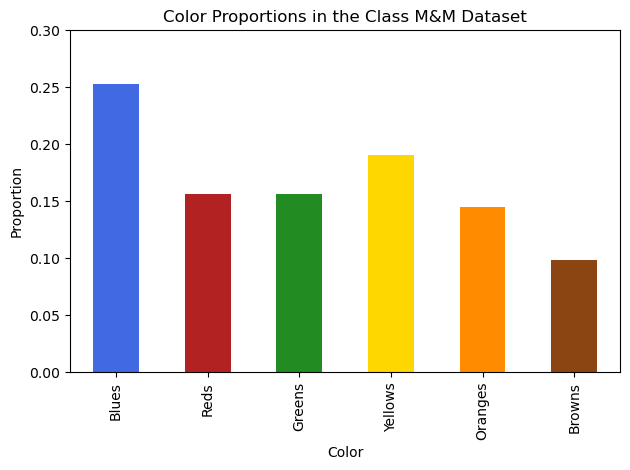

In [85]:
# Step 8

mnm_colors = {
    "Blues": "royalblue", "Browns": "saddlebrown", "Greens": "forestgreen",
    "Oranges": "darkorange", "Reds": "firebrick", "Yellows": "gold"
}

plot_colors = [mnm_colors[color] for color in overall_proportions.index]
overall_proportions.plot(kind="bar", color=plot_colors)
plt.title("Color Proportions in the Class M&M Dataset")
plt.xlabel("Color")
plt.ylabel("Proportion")
plt.ylim(0, .3)
plt.tight_layout()
plt.show()

### 9. Exention
- I chose to write a function that produces a color report for any bag. I used Claude to write this funtion. I believe that this adds to the purpose of this exercize becasue it allows for each bag to be inspected. Because my hypothesis claimed that the colors would be proportional on average across many bags, it could be beneficial to also have a way to look at them one-by-one to have a well-rounded idea of the distribution. 

In [ ]:
# Step 9

def color_report(bag_id):
    bag = df[df["bag_id"] == bag_id].iloc[0]
    total = bag["total"]
    
    print(f"Color Report {bag_id}")
    
    for color in color_cols:
        count = bag[color]
        proportion = count / total
        diff = proportion - (1/6)
        print(f"{color:<10} {count:>2}  {proportion:.1%}  (vs 1/6: {diff:+.1%})")

# test it
color_report("Bag_01")

Color Report Bag_01
Blues       6  37.5%  (vs 1/6: +20.8%)
Reds        2  12.5%  (vs 1/6: -4.2%)
Greens      1  6.2%  (vs 1/6: -10.4%)
Yellows     2  12.5%  (vs 1/6: -4.2%)
Oranges     2  12.5%  (vs 1/6: -4.2%)
Browns      3  18.8%  (vs 1/6: +2.1%)


### 10. Conclusion  
For this investigation, I was considering randomness in terms of even color distribution across many bags of M&Ms. My original hypothesis was that “across many bags of M&M's, the colors appear (on average) the same number of times in each bag because they are equally likely to appear”. The evidence I found shows this is not true; compared with the other color distributions, blue M&M appeared almost twice as many times, and brown M&M appeared almost half as many times. I can conclude that my hypothesis was incorrect, but cannot conclude anything on a larger scale, as our sample population was relatively small. The number of M&Ms in each bag was around 13-16, which is relatively small, and there were only 29 bags to draw data from. In order to strengthen this investigation, it could be beneficial to have more (30+) bags with larger quantities of M&M’s in each bag.
